In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
from sklearn.metrics import silhouette_score
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))
from db.database import Database
from util.dataframe_utils import get_dataframes
from sklearn.metrics.pairwise import cosine_distances, cosine_similarity

In [2]:
db = Database()
bp_df, topics_df, posts_df = get_dataframes(db)
bp_df.head()

,id,blueprint_hash,name,extracted_keywords,blueprint_url,blueprint_code,post_id,description,keywords_yake,topic_id,tags,created_at
0,1,2f523787adf856fbddd08b2f7b32aa2490eb48a236bc68...,Nag prompt blueprint,"{""input__input_boolean"": 2}",https://community.home-assistant.io//t/nag-pro...,blueprint:\n name: Nag prompt blueprint\n de...,1220860,Nag a mobile device to do something,"[""android notification"", ""nag prompt"", ""nag no...",255041,[],2020-12-14 01:40:32.358
1,2,ca6a74b04fac9cee0925adfe7cb03c8beb0354a816fa66...,Inovelli,{},https://community.home-assistant.io//t/inovell...,blueprint:\n name: Inovelli \n description: ...,1220678,Use this blueprint to create automations based...,"[""fan"", ""inovelli"", ""create"", ""dimmer""]",254999,"[""blueprint""]",2020-12-13 22:32:38.158
2,3,c5f67655e23dff66b1042d3b38e967d74dad01a4a3d589...,deCONZ - IKEA five button remote,"{""input__deconz"": 1}",https://community.home-assistant.io//t/deconz-...,blueprint:\n name: deCONZ - IKEA five button ...,1223455,Control anything using IKEA five button remote\n,"[""button short"", ""button remote"", ""long press""...",255699,"[""switch"", ""blueprint"", ""deconz""]",2020-12-15 12:18:15.898
3,4,00b1c4d2e847ed9451c8e8d1acfbbcd5e1740f9991226d...,Heat for certain time,"{""input__input_datetime"": 1, ""input__climate"": 2}",https://community.home-assistant.io//t/set-hea...,blueprint:\n name: Heat for certain time\n d...,1223628,Turn on heating for a given amount of time.,"[""set heating"", ""heating temperature"", ""time"",...",255742,[],2020-12-15 14:23:53.414
4,5,0dd0ec70d42f2e8a428ae7a2934852dbec0beb34cd03cc...,Light Allowance,"{""input__light"": 1, ""output__light"": 1}",https://community.home-assistant.io//t/light-a...,blueprint:\n name: Light Allowance\n descrip...,1224871,Turns a light off after an allotted time,"[""light allowance"", ""light"", ""allowance"", ""all...",256045,[],2020-12-16 04:23:36.519


In [3]:
import json, re
def process_bp_keywords(kwd_dict: dict[str, int] | str) -> list[str] | None:
    if isinstance(kwd_dict, str):
        kwd_dict = json.loads(kwd_dict)
    
    kwd_list = list(kwd_dict.keys())
    if kwd_list.__len__() < 1:
        return None
    
    kwds = []
    
    for kwd in kwd_list:
        in_out = re.search(r"(input__|output__)(input_|output_)?", kwd)
        kwd = kwd.removeprefix(in_out.group()) if in_out else kwd
        in_out = in_out.group(1) if in_out else None
        kwds.append(in_out + kwd if in_out else kwd)
    return kwds

In [4]:
from difflib import SequenceMatcher
def _normalize_feature_token(token: str) -> str:
    token = token.lower().strip()
    token = re.sub(r"[^a-z0-9]+", " ", token)
    token = re.sub(r"\s+", " ", token).strip()
    return token

def _similarity(a: str, b: str) -> float:
    return SequenceMatcher(None, a, b).ratio()

def normalize_yake_features(features: list[str], threshold: float = 0.88, min_len: int = 4) -> list[str]:
    """
    Canonicalize YAKE keywords using fuzzy matching and simple containment rules.
    Keeps original order but maps near-duplicates to a shared canonical token.
    """
    canonicals: list[str] = []
    canonical_map: dict[str, str] = {}
    for raw in features:
        norm = _normalize_feature_token(raw)
        if not norm:
            continue
        if norm in canonical_map:
            canonical = canonical_map[norm]
            canonicals.append(canonical)
            continue
        canonical = norm
        for existing in set(canonical_map.values()):
            if min(len(norm), len(existing)) >= min_len and (norm in existing or existing in norm):
                canonical = existing if len(existing) <= len(norm) else norm
                break
            if _similarity(norm, existing) >= threshold:
                canonical = existing
                break
        canonical_map[norm] = canonical
        canonicals.append(canonical)
    return canonicals

In [5]:
ignorable_tags = {"blueprint", "automation"}
bp_df["tags"] = bp_df["tags"].apply(lambda tags: [tag for tag in json.loads(tags) if tag not in ignorable_tags])
bp_df.head()

,id,blueprint_hash,name,extracted_keywords,blueprint_url,blueprint_code,post_id,description,keywords_yake,topic_id,tags,created_at
0,1,2f523787adf856fbddd08b2f7b32aa2490eb48a236bc68...,Nag prompt blueprint,"{""input__input_boolean"": 2}",https://community.home-assistant.io//t/nag-pro...,blueprint:\n name: Nag prompt blueprint\n de...,1220860,Nag a mobile device to do something,"[""android notification"", ""nag prompt"", ""nag no...",255041,[],2020-12-14 01:40:32.358
1,2,ca6a74b04fac9cee0925adfe7cb03c8beb0354a816fa66...,Inovelli,{},https://community.home-assistant.io//t/inovell...,blueprint:\n name: Inovelli \n description: ...,1220678,Use this blueprint to create automations based...,"[""fan"", ""inovelli"", ""create"", ""dimmer""]",254999,[],2020-12-13 22:32:38.158
2,3,c5f67655e23dff66b1042d3b38e967d74dad01a4a3d589...,deCONZ - IKEA five button remote,"{""input__deconz"": 1}",https://community.home-assistant.io//t/deconz-...,blueprint:\n name: deCONZ - IKEA five button ...,1223455,Control anything using IKEA five button remote\n,"[""button short"", ""button remote"", ""long press""...",255699,"[switch, deconz]",2020-12-15 12:18:15.898
3,4,00b1c4d2e847ed9451c8e8d1acfbbcd5e1740f9991226d...,Heat for certain time,"{""input__input_datetime"": 1, ""input__climate"": 2}",https://community.home-assistant.io//t/set-hea...,blueprint:\n name: Heat for certain time\n d...,1223628,Turn on heating for a given amount of time.,"[""set heating"", ""heating temperature"", ""time"",...",255742,[],2020-12-15 14:23:53.414
4,5,0dd0ec70d42f2e8a428ae7a2934852dbec0beb34cd03cc...,Light Allowance,"{""input__light"": 1, ""output__light"": 1}",https://community.home-assistant.io//t/light-a...,blueprint:\n name: Light Allowance\n descrip...,1224871,Turns a light off after an allotted time,"[""light allowance"", ""light"", ""allowance"", ""all...",256045,[],2020-12-16 04:23:36.519


In [6]:
max_keywords = bp_df["extracted_keywords"].apply(lambda x: len(json.loads(x)) if isinstance(x, str) else 0).max() 
max_tags = bp_df["tags"].apply(lambda x: len(x) if isinstance(x, list) else 0).max()
max_yake = 4
max_features = max_keywords + max_tags + max_yake
max_keywords, max_tags, max_features

(15, 5, 24)

In [7]:
def extract_features(row, max_features=max_features):
    padding = "<PAD>"
    
    yake_features = json.loads(row["keywords_yake"])
    yake_features = normalize_yake_features(yake_features)
    combined_features = list(yake_features)
    ext_kw = process_bp_keywords(row["extracted_keywords"])
    if ext_kw:
        combined_features.extend(ext_kw)
    
    kw_n = max_keywords - len(ext_kw) if ext_kw else max_keywords
    combined_features += [padding] * kw_n
    
    tags = row["tags"]
    tag_n = max_tags - len(tags)
    combined_features.extend(tags)
    combined_features += [padding] * tag_n

    return combined_features

In [8]:
bp_df["features"] = bp_df.apply(extract_features, axis=1)
bp_df.head()

,id,blueprint_hash,name,extracted_keywords,blueprint_url,blueprint_code,post_id,description,keywords_yake,topic_id,tags,created_at,features
0,1,2f523787adf856fbddd08b2f7b32aa2490eb48a236bc68...,Nag prompt blueprint,"{""input__input_boolean"": 2}",https://community.home-assistant.io//t/nag-pro...,blueprint:\n name: Nag prompt blueprint\n de...,1220860,Nag a mobile device to do something,"[""android notification"", ""nag prompt"", ""nag no...",255041,[],2020-12-14 01:40:32.358,"[android notification, nag prompt, nag notific..."
1,2,ca6a74b04fac9cee0925adfe7cb03c8beb0354a816fa66...,Inovelli,{},https://community.home-assistant.io//t/inovell...,blueprint:\n name: Inovelli \n description: ...,1220678,Use this blueprint to create automations based...,"[""fan"", ""inovelli"", ""create"", ""dimmer""]",254999,[],2020-12-13 22:32:38.158,"[fan, inovelli, create, dimmer, <PAD>, <PAD>, ..."
2,3,c5f67655e23dff66b1042d3b38e967d74dad01a4a3d589...,deCONZ - IKEA five button remote,"{""input__deconz"": 1}",https://community.home-assistant.io//t/deconz-...,blueprint:\n name: deCONZ - IKEA five button ...,1223455,Control anything using IKEA five button remote\n,"[""button short"", ""button remote"", ""long press""...",255699,"[switch, deconz]",2020-12-15 12:18:15.898,"[button short, button remote, long press, butt..."
3,4,00b1c4d2e847ed9451c8e8d1acfbbcd5e1740f9991226d...,Heat for certain time,"{""input__input_datetime"": 1, ""input__climate"": 2}",https://community.home-assistant.io//t/set-hea...,blueprint:\n name: Heat for certain time\n d...,1223628,Turn on heating for a given amount of time.,"[""set heating"", ""heating temperature"", ""time"",...",255742,[],2020-12-15 14:23:53.414,"[set heating, heating temperature, time, set, ..."
4,5,0dd0ec70d42f2e8a428ae7a2934852dbec0beb34cd03cc...,Light Allowance,"{""input__light"": 1, ""output__light"": 1}",https://community.home-assistant.io//t/light-a...,blueprint:\n name: Light Allowance\n descrip...,1224871,Turns a light off after an allotted time,"[""light allowance"", ""light"", ""allowance"", ""all...",256045,[],2020-12-16 04:23:36.519,"[light allowance, light, allowance, allotted, ..."


In [11]:
from sklearn.preprocessing import normalize
model = SentenceTransformer('all-MiniLM-L6-v2')

# Apply the updated function
bp_df["features"] = bp_df.apply(lambda row: extract_features(row, max_features=15), axis=1)

bp_df["features"] = bp_df["features"].apply(lambda x: " ".join(x))  # Combine list of strings into a single string
bp_df["embeddings"] = bp_df["features"].apply(lambda x: model.encode(x))

# Create a feature matrix
X = np.vstack(bp_df["embeddings"].values)
X_normalized = normalize(X, norm='l2')

In [19]:
from collections import Counter

def analyze_cluster_features(bp_df, cluster_id=None, fine_cluster=None, top_n=10):
    """Analyze the most common features in a specific cluster"""
    if cluster_id is not None and fine_cluster is not None:
        raise ValueError("Provide either cluster_id or fine_cluster, not both.")
    if cluster_id is not None:
        cluster_data = bp_df[bp_df["top_cluster"] == cluster_id]
    elif fine_cluster is not None:
        cluster_data = bp_df[bp_df["fine_cluster"] == fine_cluster]
    else:
        raise ValueError("Either cluster_id or fine_cluster must be provided.")
    
    all_features = []
    for features in cluster_data["features"]:
        feature_list = [f for f in features.split() if f != "<PAD>"]
        all_features.extend(feature_list)
    
    feature_counts = Counter(all_features)
    
    return feature_counts.most_common(top_n)

### Two-stage KMeans (top-down)

In [10]:
k_top = 15
kmeans_top = KMeans(n_clusters=k_top, random_state=42)
bp_df["top_cluster"] = kmeans_top.fit_predict(X_normalized)

In [11]:
bp_df["sub_cluster"] = -1

for c in range(k_top):
    mask = bp_df["top_cluster"] == c
    X_sub = X_normalized[mask]
    
    if len(X_sub) < 10:
        continue
    
    k_sub = min(5, len(X_sub) // 5)
    km = KMeans(n_clusters=k_sub, random_state=42)

    bp_df.loc[mask, "sub_cluster"] = km.fit_predict(X_sub)

In [ ]:
def write_to_md(filename: str):    
    with open(filename, "w", encoding="utf-8") as f:
        for cluster_id in range(kmeans_top.n_clusters):
            f.write(f"<details>\n")
            features = analyze_cluster_features(bp_df, cluster_id=cluster_id, top_n=5)
            f.write(f"<summary> Cluster {cluster_id} </summary>\n\n")
            f.write(f"Top 5 features: \n")
            for feature, count in features:
                f.write(f"- {feature}: {count} \n")
            f.write("\n")
            sub_clusters = bp_df[bp_df["top_cluster"] == cluster_id]["sub_cluster"].unique()
            f.write(f"Sub-clusters: {', '.join(map(str, sub_clusters))} \n\n")
            for sub_cluster in sub_clusters:
                bps = bp_df[(bp_df["top_cluster"] == cluster_id) & (bp_df["sub_cluster"] == sub_cluster)]
                f.write(f"### Sub-cluster {sub_cluster}\n\n")
                for idx, bp in bps.iterrows():
                    post_url = topics_df[topics_df["post_id"] == bp["post_id"]]["post_url"].values[0]
                    f.write(f"- {bp['name']}, [Link]({post_url}) \n")
                f.write("\n")
c_name = "hierarchical_clusters_norm_15_5"
write_to_md(f"output/{c_name}.md")

### Agglomerative clustering on centroids (bottom-up)

In [24]:
kmeans = KMeans(n_clusters=55, random_state=42)
bp_df["fine_cluster"] = kmeans.fit_predict(X_normalized)

centroids = kmeans.cluster_centers_

In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=14, metric="cosine", linkage="average")

top_labels = agg.fit_predict(centroids)

In [25]:
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.35,
    metric="cosine",
    linkage="average"
)

top_labels = agg.fit_predict(centroids)

In [26]:
bp_df["top_cluster"] = bp_df["fine_cluster"].map(dict(enumerate(top_labels)))
bp_df.head()

,id,blueprint_hash,name,extracted_keywords,blueprint_url,blueprint_code,post_id,description,keywords_yake,topic_id,tags,created_at,features,embeddings,fine_cluster,top_cluster
0,1,2f523787adf856fbddd08b2f7b32aa2490eb48a236bc68...,Nag prompt blueprint,"{""input__input_boolean"": 2}",https://community.home-assistant.io//t/nag-pro...,blueprint:\n name: Nag prompt blueprint\n de...,1220860,Nag a mobile device to do something,"[""android notification"", ""nag prompt"", ""nag no...",255041,[],2020-12-14 01:40:32.358,android notification nag prompt nag notificati...,"[0.01281304, -0.02289014, 0.050583474, -0.0862...",42,3
1,2,ca6a74b04fac9cee0925adfe7cb03c8beb0354a816fa66...,Inovelli,{},https://community.home-assistant.io//t/inovell...,blueprint:\n name: Inovelli \n description: ...,1220678,Use this blueprint to create automations based...,"[""fan"", ""inovelli"", ""create"", ""dimmer""]",254999,[],2020-12-13 22:32:38.158,fan inovelli create dimmer <PAD> <PAD> <PAD> <...,"[-0.0039998735, -0.04323262, 0.007992302, 0.02...",38,4
2,3,c5f67655e23dff66b1042d3b38e967d74dad01a4a3d589...,deCONZ - IKEA five button remote,"{""input__deconz"": 1}",https://community.home-assistant.io//t/deconz-...,blueprint:\n name: deCONZ - IKEA five button ...,1223455,Control anything using IKEA five button remote\n,"[""button short"", ""button remote"", ""long press""...",255699,"[switch, deconz]",2020-12-15 12:18:15.898,button short button remote long press button i...,"[-0.014756544, -0.056055095, -0.04967789, -0.0...",8,1
3,4,00b1c4d2e847ed9451c8e8d1acfbbcd5e1740f9991226d...,Heat for certain time,"{""input__input_datetime"": 1, ""input__climate"": 2}",https://community.home-assistant.io//t/set-hea...,blueprint:\n name: Heat for certain time\n d...,1223628,Turn on heating for a given amount of time.,"[""set heating"", ""heating temperature"", ""time"",...",255742,[],2020-12-15 14:23:53.414,set heating heating temperature time set input...,"[0.03480944, 0.004590909, -0.06048607, 0.02017...",29,0
4,5,0dd0ec70d42f2e8a428ae7a2934852dbec0beb34cd03cc...,Light Allowance,"{""input__light"": 1, ""output__light"": 1}",https://community.home-assistant.io//t/light-a...,blueprint:\n name: Light Allowance\n descrip...,1224871,Turns a light off after an allotted time,"[""light allowance"", ""light"", ""allowance"", ""all...",256045,[],2020-12-16 04:23:36.519,light allowance light allowance allotted input...,"[0.032050636, 0.004219349, -0.048972845, -0.00...",20,4


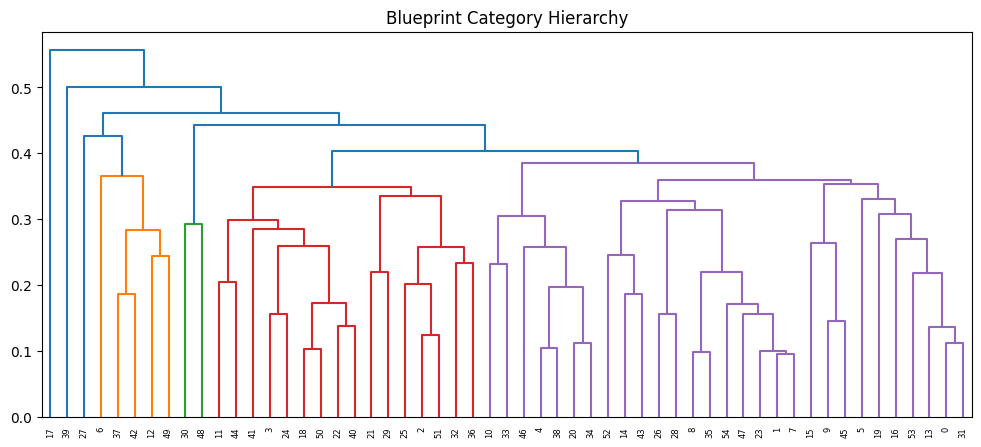

In [27]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(centroids, method="average", metric="cosine")

plt.figure(figsize=(12, 5))
dendrogram(Z)
plt.title("Blueprint Category Hierarchy")
plt.show()

In [28]:
bp_df["top_cluster"].unique().shape

(11,)

In [ ]:
def write_to_md(filename: str):    
    with open(filename, "w", encoding="utf-8") as f:
        for cluster_id in range(agg.n_clusters_):
            f.write(f"<details>\n")
            features = analyze_cluster_features(bp_df, cluster_id=cluster_id, top_n=5)
            f.write(f"<summary> Cluster {cluster_id} </summary>\n\n")
            f.write(f"Top 5 features: \n")
            for feature, count in features:
                f.write(f"- {feature}: {count} \n")
            f.write("\n")
            fine_clusters = bp_df[bp_df["top_cluster"] == cluster_id]["fine_cluster"].unique()
            f.write(f"Sub-clusters: {', '.join(map(str, fine_clusters))} \n\n")
            for fine_cluster in fine_clusters:
                f.write(f"<details>\n")
                f.write(f"<summary> Sub-cluster {fine_cluster} </summary>\n\n")
                features = analyze_cluster_features(bp_df, fine_cluster=fine_cluster, top_n=5)
                f.write(f"Top 5 features: \n")
                for feature, count in features:
                    f.write(f"- {feature}: {count} \n")
                f.write("\n")
                bps = bp_df[(bp_df["top_cluster"] == cluster_id) & (bp_df["fine_cluster"] == fine_cluster)]
                for idx, bp in bps.iterrows():
                    post_url = topics_df[topics_df["post_id"] == bp["post_id"]]["post_url"].values[0]
                    f.write(f"- {bp['name']}, [Link]({post_url}) \n")
                f.write("\n")
                f.write(f"</details>\n\n")
            f.write(f"</details>\n\n")
c_name = "agg_clusters_d_threshold_55_fine"
write_to_md(f"output/{c_name}.md")

In [21]:
parab_1 = bp_df[bp_df["topic_id"] == "673747"]
parab_2 = bp_df[bp_df["topic_id"] == "889302"]
parab_3 = bp_df[bp_df["topic_id"] == "255193"]
parab_1["tags"].tolist()[0], parab_1["extracted_keywords"].tolist(), parab_1["keywords_yake"].tolist()

(['script', 'lights', 'alarm'],
 ['{"input__input_datetime": 1, "input__sensor": 1, "input__timestamp": 1, "input__binary_sensor": 1, "input__person": 1, "input__light": 6, "output__script": 3}',
  '{"input__input_datetime": 1, "input__binary_sensor": 1, "input__light": 5, "output__script": 3}'],
 ['["time", "script", "alarm", "start time"]',
  '["time", "script", "alarm", "start time"]'])

In [22]:
parab_2["tags"].tolist()[0], parab_2["extracted_keywords"].tolist(), parab_2["keywords_yake"].tolist()

(['script', 'lights', 'automating-lights'],
 ['{"input__switch": 1, "input__binary_sensor": 1, "input__input_boolean": 1, "input__input_button": 1, "input__light": 6, "output__script": 3}'],
 ['["script", "light", "post actions", "parabolic sunset"]'])

In [23]:
parab_3["tags"].tolist()[0], parab_3["extracted_keywords"].tolist(), parab_3["keywords_yake"].tolist()

([],
 ['{"input__light": 4}',
  '{"input__light": 5}',
  '{"input__light": 4}',
  '{"input__light": 4, "input__media_player": 3}',
  '{"input__light": 4}'],
 ['["time", "alarm time"]',
  '["time", "alarm time", "alarm", "light"]',
  '["time", "alarm time", "alarm", "light"]',
  '["time", "alarm time", "alarm", "light"]',
  '["time", "alarm time", "alarm", "light"]'])